In [ ]:
import openml
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ----------------------------
# Load OpenML task -> X, y
# ----------------------------
task_id = 363615
task = openml.tasks.get_task(task_id)
dataset = task.get_dataset()

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)

# ----------------------------
# Train / test split (7:3)
# ----------------------------

train_indices, test_indices = task.get_train_test_split_indices(fold=0, repeat=0)
X_train = X.iloc[train_indices].reset_index(drop=True)
X_test = X.iloc[test_indices].reset_index(drop=True)

# Convert y based on task type
y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

# ----------------------------
# Fit EBM regressor
# ----------------------------
ebm = ExplainableBoostingRegressor(
    interactions=10,     # let EBM learn up to 10 pairwise interactions
    random_state=42,
    outer_bags=4,
    max_bins=256
)

ebm.fit(X_train, y_train)




ExplainableBoostingRegressor(interactions=10, max_bins=256, outer_bags=4)

In [103]:
# ----------------------------
# Evaluation
# ----------------------------
y_pred = ebm.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R2: 0.8516525587862035
RMSE: 538331.0892380562


In [104]:
show(ebm.explain_global())

<!-- http://127.0.0.1:7001/2520887983440/ -->

In [ ]:
import openml
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ----------------------------
# Load OpenML task -> X, y
# ----------------------------
task_id = 363615
task = openml.tasks.get_task(task_id)
dataset = task.get_dataset()

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)

# ----------------------------
# Train / test split (7:3)
# ----------------------------
train_indices, test_indices = task.get_train_test_split_indices(fold=0, repeat=0)
X_train = X.iloc[train_indices].reset_index(drop=True)
X_test = X.iloc[test_indices].reset_index(drop=True)

# Convert y based on task type
y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

# ----------------------------
# Manually selected interactions
# ----------------------------
raw_interactions = [
    (0, 2),
    (0, 2, 3),
    (2, 3),
    (2, 5),
    (0, 2, 5, 6),
    (0, 2, 5),
    (0, 3),
    (0, 2, 6),
    (0, 5),
    (0, 5, 6),
]

# manual_interactions = [t for t in raw_interactions if len(t) == 2]

# ----------------------------
# Fit SPEX-EBM regressor
# This takes a long time to run
# ----------------------------
# spex_ebm = ExplainableBoostingRegressor(
#     interactions=raw_interactions,  # use manually selected 2-way interactions
#     random_state=42,
#     outer_bags=4,
#     max_bins=256
# )

# spex_ebm.fit(X_train, y_train)

# # ----------------------------
# # Evaluation
# # ----------------------------
# y_pred = spex_ebm.predict(X_test)

# print("R2:", r2_score(y_test, y_pred))
# print("RMSE:", mean_squared_error(y_test, y_pred))


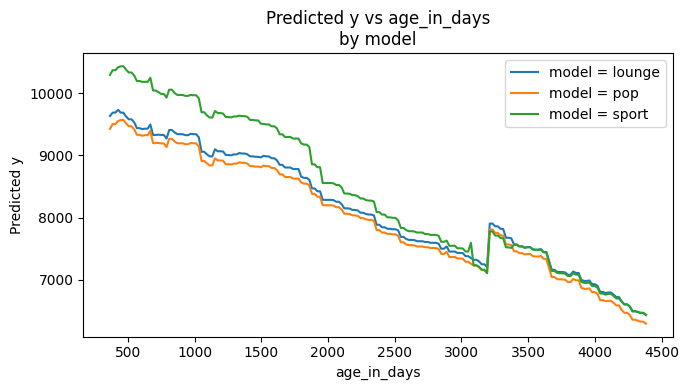

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_predicted_y_disc_cont(
    model,
    X,
    disc_idx=0,
    cont_idx=2,
    num_points=200
):
    """
    Plot predicted_y vs continuous feature (cont_idx),
    with separate lines for each category of discrete feature (disc_idx).
    """

    # 1) Prepare baseline row (mean for numeric, mode for categorical)
    baseline = {}
    for col in X.columns:
        if X[col].dtype.kind in "if":  # numeric
            baseline[col] = X[col].mean()
        else:  # categorical / discrete
            baseline[col] = X[col].mode()[0]

    # 2) Continuous axis values
    low, high = np.percentile(
        X.iloc[:, cont_idx].dropna().to_numpy(),
        [2.5, 97.5]
    )

    x_vals = np.linspace(low, high, num_points)


    # 3) Discrete levels (you said there are exactly 3)
    disc_col = X.columns[disc_idx]
    cont_col = X.columns[cont_idx]
    disc_levels = sorted(X.iloc[:, disc_idx].unique())

    # 4) Plot
    plt.figure(figsize=(7, 4))

    for lvl in disc_levels:
        X_plot = pd.DataFrame(
            {col: [baseline[col]] * num_points for col in X.columns}
        )
        X_plot[cont_col] = x_vals
        X_plot[disc_col] = lvl

        y_pred = model.predict(X_plot)

        plt.plot(x_vals, y_pred, label=f"{disc_col} = {lvl}")

    plt.xlabel(cont_col)
    plt.ylabel("Predicted y")
    plt.title(f"Predicted y vs {cont_col}\nby {disc_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---- Your case ----
plot_predicted_y_disc_cont(
    model=spex_ebm,
    X=X,
    disc_idx=0,
    cont_idx=2
)


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_lat_lon_heatmaps(
    X,
    y,
    model_idx=0,
    lat_idx=5,
    lon_idx=6,
    gridsize=30,
    max_points=5000,
    save_path=None,          # <-- NEW
):
    model_col = X.columns[model_idx]
    lat_col = X.columns[lat_idx]
    lon_col = X.columns[lon_idx]

    df = X[[model_col, lat_col, lon_col]].copy()
    df["y"] = y.values

    if len(df) > max_points:
        df = df.sample(max_points, random_state=42)

    df["model_group"] = df[model_col].apply(
        lambda v: "sport" if v == "sport" else "not sport"
    )
    groups = ["sport", "not sport"]

    vmin, vmax = df["y"].quantile([0.05, 0.95])

    fig, axes = plt.subplots(
        1, len(groups),
        figsize=(4 * len(groups) + 1, 4),
        sharex=True,
        sharey=True,
        gridspec_kw={"right": 0.88}
    )
    cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])

    hb_last = None
    for ax, g in zip(axes, groups):
        sub = df[df["model_group"] == g]

        hb_last = ax.hexbin(
            sub[lon_col],
            sub[lat_col],
            C=sub["y"],
            reduce_C_function=np.mean,
            gridsize=gridsize,
            cmap="plasma",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(g)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        # Add subtle gray gridlines
        ax.grid(
            True,
            color="lightgray",
            linestyle="--",
            linewidth=0.5,
            alpha=0.6
        )
        ax.set_axisbelow(True)


    fig.colorbar(hb_last, cax=cax, label="Selling Price")

    plt.suptitle("Spatial heatmap of selling price")
    plt.tight_layout(rect=[0, 0, 0.88, 1])

    # --- Save to PDF if requested ---
    if save_path is not None:
        plt.savefig(save_path, format="pdf", bbox_inches="tight")
        print(f"Saved heatmap to {save_path}")

    plt.show()


C:\Users\cloud\AppData\Local\Temp\ipykernel_48360\570067499.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


Saved heatmap to sport_vs_not_sport_heatmap.pdf


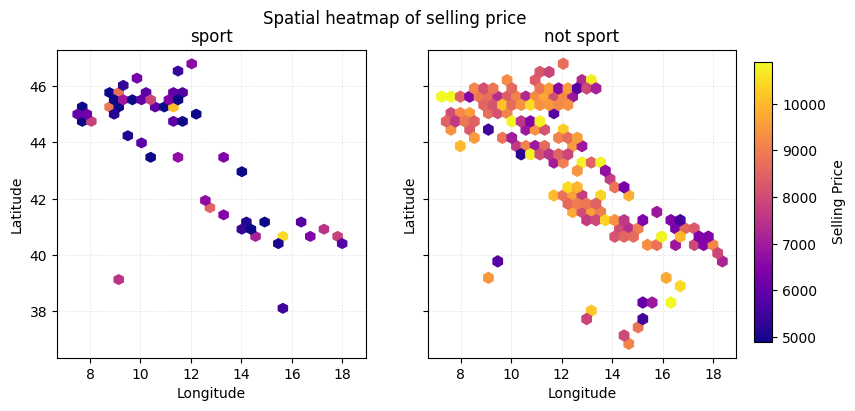

In [18]:
plot_model_lat_lon_heatmaps(
    X=X,
    y=y,
    model_idx=0,
    lat_idx=5,
    lon_idx=6,
    save_path="sport_vs_not_sport_heatmap.pdf"
)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_model_location_mean_variance(
    X,
    y,
    model_idx=0,
    lat_idx=5,
    lon_idx=6,
    save_path=None,
):
    # Get column names
    model_col = X.columns[model_idx]
    lat_col = X.columns[lat_idx]
    lon_col = X.columns[lon_idx]

    # Build dataframe
    df = X[[model_col, lat_col, lon_col]].copy()
    df["y"] = y.values

    # Collapse model type into two groups
    df["model_group"] = df[model_col].apply(
        lambda v: "sport" if v == "sport" else "not sport"
    )

    # Split location into 2x2 cells using medians
    lon_cut = df[lon_col].median()
    lat_cut = df[lat_col].median()

    df["lon_bin"] = np.where(df[lon_col] <= lon_cut, "West", "East")
    df["lat_bin"] = np.where(df[lat_col] <= lat_cut, "South", "North")
    df["cell"] = df["lat_bin"] + "-" + df["lon_bin"]

    cell_order = ["South-West", "South-East", "North-West", "North-East"]
    group_order = ["sport", "not sport"]

    # Aggregate mean / variance / std / count
    summary = (
        df.groupby(["cell", "model_group"])["y"]
        .agg(["mean", "var", "std", "count"])
        .reset_index()
    )

    # Reindex to keep consistent plotting order
    full_index = pd.MultiIndex.from_product(
        [cell_order, group_order], names=["cell", "model_group"]
    )
    summary = (
        summary.set_index(["cell", "model_group"])
        .reindex(full_index)
        .reset_index()
    )

    # Plot
    fig, ax = plt.subplots(figsize=(9, 5.5))

    x = np.arange(len(cell_order))
    offsets = {"sport": -0.15, "not sport": 0.15}

    for group in group_order:
        sub = summary[summary["model_group"] == group].copy()
        x_pos = x + offsets[group]

        ax.errorbar(
            x_pos,
            sub["mean"],
            yerr=sub["std"],
            fmt="o",
            capsize=5,
            label=group,
        )

        # Annotate variance and sample size
        for xi, mean_val, var_val, n_val in zip(
            x_pos, sub["mean"], sub["var"], sub["count"]
        ):
            if pd.notna(mean_val):
                ax.text(
                    xi,
                    mean_val,
                    f"var={var_val:.0f}\nn={int(n_val)}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(cell_order)
    ax.set_ylabel("Selling Price")
    ax.set_title("Mean and variance of selling price by model type across 2×2 location cells")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(title="Model Type")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, format="pdf", bbox_inches="tight")
        print(f"Saved figure to {save_path}")

    plt.show()

    print(summary)

C:\Users\cloud\AppData\Local\Temp\ipykernel_35032\3897244194.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\cloud\AppData\Local\Temp\ipykernel_35032\3897244194.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\cloud\AppData\Local\Temp\ipykernel_35032\3897244194.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\cloud\AppData\Local\Temp\ipykernel_35032\3897244194.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxpl

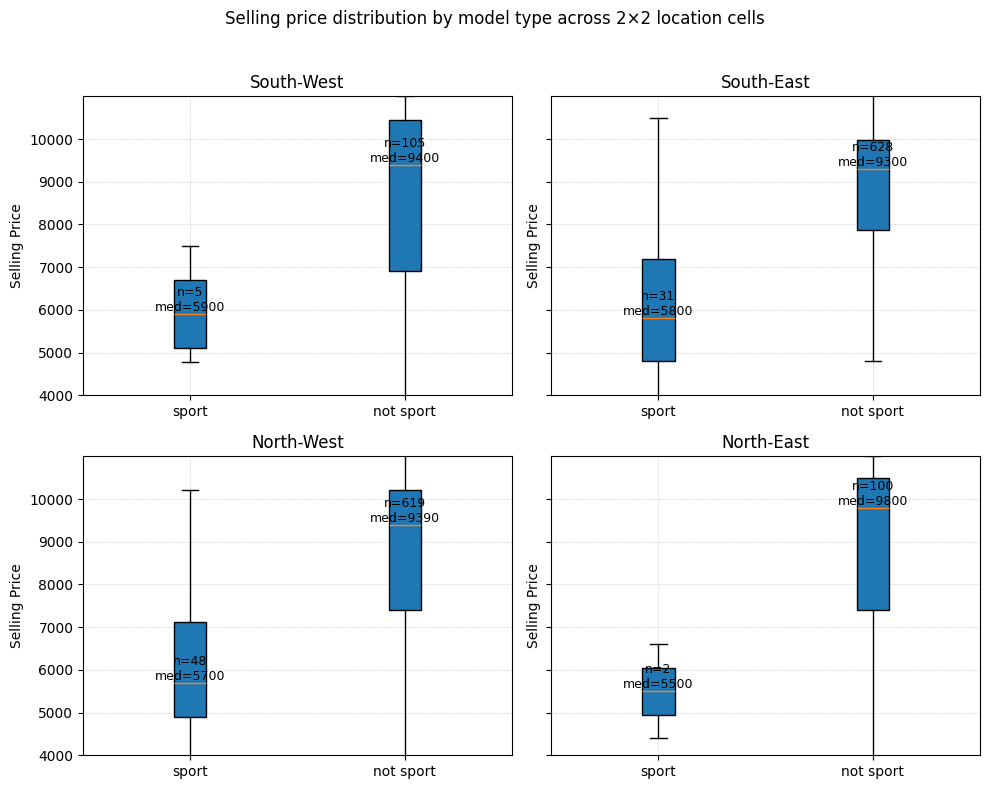

         cell model_group  count         mean  median          std
0  North-East   not sport    100  8839.300000  9800.0  1930.477936
1  North-East       sport      2  5500.000000  5500.0  1555.634919
2  North-West   not sport    619  8681.843296  9390.0  1908.123244
3  North-West       sport     48  6356.416667  5700.0  2026.457582
4  South-East   not sport    628  8761.020701  9300.0  1754.841812
5  South-East       sport     31  6244.741935  5800.0  1912.785804
6  South-West   not sport    105  8479.019048  9400.0  2035.410991
7  South-West       sport      5  5998.000000  5900.0  1120.722981

Mean gap (sport - not sport) by cell:
cell
South-West   -2481.019048
South-East   -2516.278765
North-West   -2325.426629
North-East   -3339.300000
dtype: float64

Median gap (sport - not sport) by cell:
cell
South-West   -3500.0
South-East   -3500.0
North-West   -3690.0
North-East   -4300.0
dtype: float64


In [ ]:
plot_model_location_mean_variance(
    X=X,
    y=y,
    model_idx=0,
    lat_idx=5,
    lon_idx=6
)
